#### Supplement Sales Data Analysis - EDA Project 

## Objective
The objective of this project is to analyze supplement sales data to identify
sales trends, product performance, and revenue patterns, and to derive
actionable business insights for decision-making.

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

In [114]:
warnings.filterwarnings("ignore")

In [115]:
df=pd.read_csv("Supplement_Sales_Weekly_Expanded.csv")

Supplement Sales Data (2020–2025)
## Overview
This dataset contains weekly sales data for a variety of health and wellness supplements from January 2020 to April 2025. The data includes products in categories like Protein, Vitamins, Omega, and Amino Acids, among others, and covers multiple e-commerce platforms such as Amazon, Walmart, and iHerb. The dataset also tracks sales in several locations including the USA, UK, and Canada.

In [116]:
df.head(2)

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon


## Data Cleaning and Preprocessing
The dataset was checked for missing values, duplicate records, and incorrect
data types. Date columns were converted to datetime format to ensure
consistency for time-based analysis.

In [117]:
df["Date"]= pd.to_datetime(df["Date"])

In [118]:
df.isna().sum().sum()

0

In [119]:
df.duplicated().sum()

0

In [120]:
df.describe()

,Date,Units Sold,Price,Revenue,Discount,Units Returned
count,4384,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000
mean,2022-08-18 12:00:00,150.200274,34.781229,5226.569446,0.124398,1.531478
min,2020-01-06 00:00:00,103.000000,10.000000,1284.000000,0.000000,0.000000
25%,2021-04-26 00:00:00,142.000000,22.597500,3349.372500,0.060000,1.000000
50%,2022-08-18 12:00:00,150.000000,34.720000,5173.140000,0.120000,1.000000
75%,2023-12-11 00:00:00,158.000000,46.712500,7009.960000,0.190000,2.000000
max,2025-03-31 00:00:00,194.000000,59.970000,10761.850000,0.250000,8.000000
std,NaN,12.396099,14.198309,2192.491946,0.071792,1.258479


In [121]:
df.describe(include="object")

,Product Name,Category,Location,Platform
count,4384,4384,4384,4384
unique,16,10,3,3
top,Whey Protein,Vitamin,Canada,iHerb
freq,274,822,1507,1499


In [122]:
daily_sales = df.groupby("Date").agg({
    "Revenue": "sum",
    "Units Sold": "sum",
    "Units Returned": "sum"
}).reset_index()

In [123]:
daily_sales

,Date,Revenue,Units Sold,Units Returned
0,2020-01-06,71848.56,2406,19
1,2020-01-13,72416.18,2374,27
2,2020-01-20,76152.42,2370,26
3,2020-01-27,70306.73,2397,29
4,2020-02-03,98011.64,2384,34
...,...,...,...,...
269,2025-03-03,66065.44,2431,36
270,2025-03-10,92509.57,2411,30
271,2025-03-17,65590.53,2381,22
272,2025-03-24,69778.44,2416,27


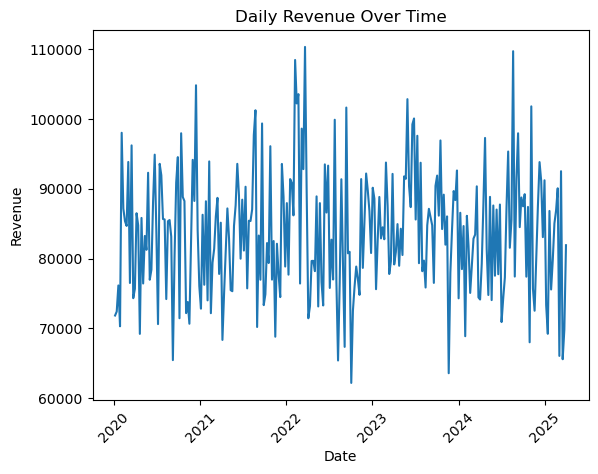

In [124]:
sns.lineplot(x="Date", y="Revenue", data=daily_sales)
plt.title("Daily Revenue Over Time")
plt.xticks(rotation=45)
plt.show()

### Insights
- The visualization shows balanced plot where yearly averages are similar.
- Years 2022 and 2024 show peak revenue.

In [125]:
category_revenue = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

In [126]:
category_revenue

Category
Vitamin        4300224.68
Mineral        4276107.99
Performance    2909702.18
Protein        2855492.09
Amino Acid     1464819.63
Omega          1451065.87
Fat Burner     1440900.05
Hydration      1411951.38
Herbal         1405700.79
Sleep Aid      1397315.79
Name: Revenue, dtype: float64

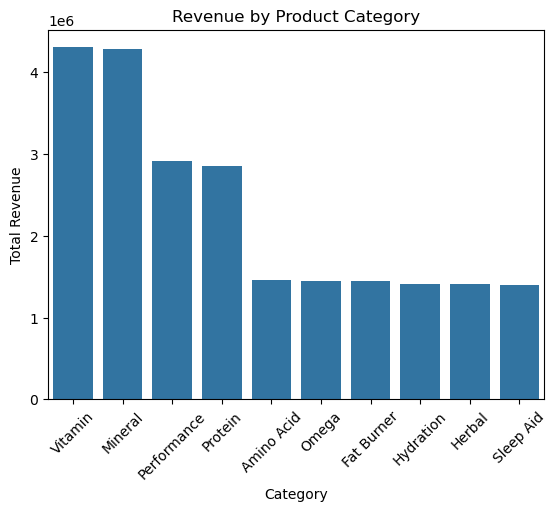

In [127]:
sns.barplot(x = category_revenue.index, y = category_revenue.values)
plt.title("Revenue by Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

### Insights
- Revenue varies across product categories.
- Vitamin category has generated the highest revenue followed by Mineral, Performance and Protein categories.
Categories like Omega, Herbal and Sleep aid have contributes significantly lesser than other categories.
- High-revenue categories are key contributors to overall sales.
- Low-revenue categories may need better promotion or review.

In [128]:
loc_platform = df.groupby(["Location","Platform"])["Revenue"].sum().unstack().fillna(0)

In [129]:
loc_platform

Platform,Amazon,Walmart,iHerb
Location,,,
Canada,2613844.28,2518639.07,2716096.38
UK,2442671.23,2637066.25,2624222.86
USA,2612936.27,2232862.30,2514941.81


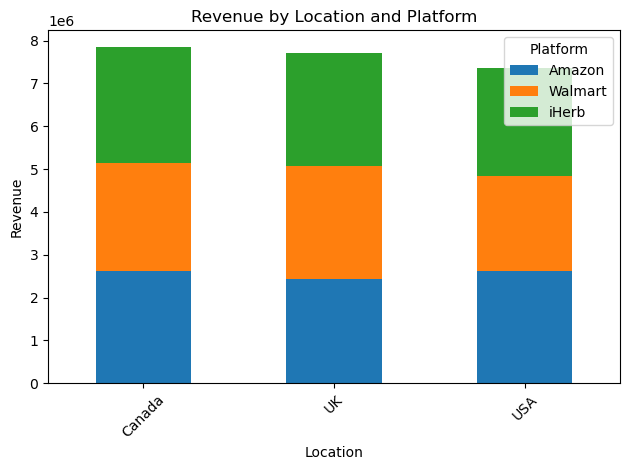

In [130]:
loc_platform.plot(kind = "bar", stacked = True)
plt.title("Revenue by Location and Platform")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### Insights
- Revenue varies across different locations and platforms.
- Canada among all the locations generates highest revenue from the platform iHerb.
USA generates least amount of revenue.
- High-performing areas and platforms are key drivers of total revenue.
- Lower-performing ones may need better marketing or improvement strategies.


In [131]:
top_products=df.groupby("Product Name")['Revenue'].sum().sort_values(ascending= False).head(10)

In [132]:
top_products

Product Name
Biotin               1486798.62
Zinc                 1482546.95
Pre-Workout          1477183.78
BCAA                 1464819.63
Fish Oil             1451065.87
Green Tea Extract    1440900.05
Collagen Peptides    1433297.24
Creatine             1432518.40
Iron Supplement      1431582.41
Whey Protein         1422194.85
Name: Revenue, dtype: float64

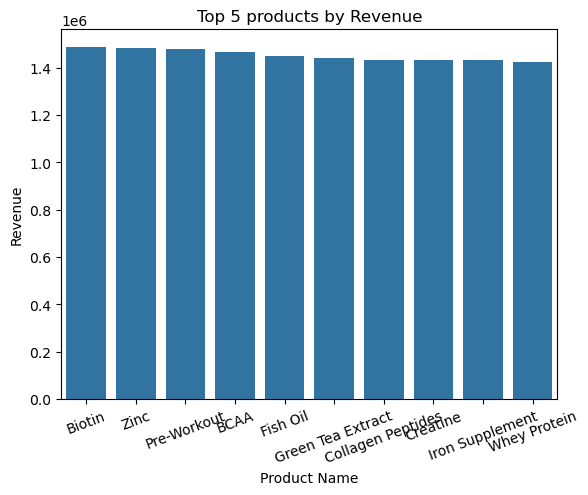

In [133]:
sns.barplot(x=top_products.index, y=top_products.values)
plt.title("Top 5 products by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation = 20.5)
plt.show()

### Insights
- The top 5 products generate a major share of total revenue.
- Biotin is the leader, generating highest revenue whereas Whey Protein generates least revenue among the top 10 products.
- These products are key drivers of overall business performance.


In [134]:
df["Return Rate"]=df["Units Returned"] / df["Units Sold"]

In [135]:
category_return = df.groupby("Category")["Return Rate"].mean().sort_values(ascending= False)

In [136]:
category_return

Category
Hydration      0.010746
Vitamin        0.010475
Amino Acid     0.010355
Fat Burner     0.010229
Performance    0.010207
Protein        0.010203
Mineral        0.010079
Omega          0.009870
Sleep Aid      0.009860
Herbal         0.009433
Name: Return Rate, dtype: float64

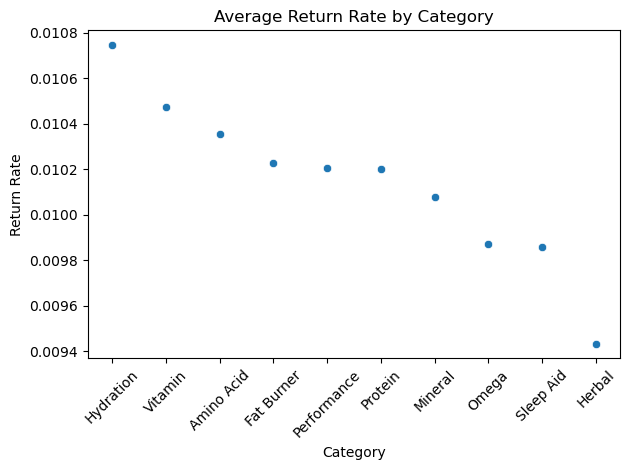

In [137]:
sns.scatterplot(x=category_return.index, y=category_return.values)
plt.title("Average Return Rate by Category")
plt.ylabel("Return Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insights
- The average return rate varies across product categories.
- Hydration category has the highest return rate whereas Herbal has the least return rate among all the categories.
- Categories with higher return rates may require quality checks or customer feedback analysis.


In [138]:
corr= df[["Units Sold", "Price", "Discount", "Revenue", "Units Returned"]].corr()

In [139]:
corr

,Units Sold,Price,Discount,Revenue,Units Returned
Units Sold,1.000000,0.013749,-0.010435,0.210462,0.116523
Price,0.013749,1.000000,-0.008668,0.977198,-0.010410
Discount,-0.010435,-0.008668,1.000000,-0.012531,0.004276
Revenue,0.210462,0.977198,-0.012531,1.000000,0.012432
Units Returned,0.116523,-0.010410,0.004276,0.012432,1.000000


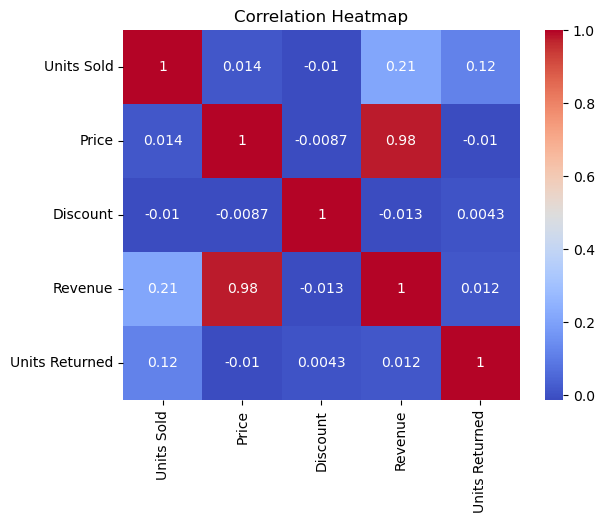

In [140]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Insights
- Correlation measures how strongly variables move together.
- Values range from: +1 → strong positive relationship , 0 → no relationship , -1 → strong negative relationship
- Revenue shows a strong positive correlation with Price.
- Price and Discount may have varying influence on sales and revenue.
- Units Returned appears less strongly correlated with overall revenue.
- Strong correlations help identify key factors affecting business performance.


In [141]:
fig=px.line(df, x="Date", y="Revenue", color="Category", title="Revenue over Time by Category")
fig.show()

### Insights
- This Plotly chart is an interactive chart, helpful to identify trends.
- Useful to analyze information, monthly or yearly, and see how different categories performed in that specific range easily.

## Feature Engineering
New time-based feature such as Month is created to allow trend analysis to calculate Monthly Revenue Trend.

In [142]:
df['Month'] = df['Date'].dt.month_name()
monthly_revenue = df.groupby('Month')['Revenue'].sum().reset_index()
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_revenue['Month'] = pd.Categorical(
    monthly_revenue['Month'],
    categories=month_order,
    ordered=True
)

monthly_revenue = monthly_revenue.sort_values('Month')

In [143]:
monthly

,Monthly,Revenue,Units Sold,Units Returned,Discount
0,2020-01,290723.89,9547,101,0.120313
1,2020-02,355213.26,9493,91,0.128125
2,2020-03,416547.17,12145,123,0.111375
3,2020-04,326287.92,9605,91,0.138281
4,2020-05,333210.99,9557,90,0.119375
...,...,...,...,...,...
58,2024-11,329894.33,9838,106,0.117813
59,2024-12,446728.99,12042,99,0.127125
60,2025-01,304965.15,9617,92,0.125156
61,2025-02,341768.25,9542,103,0.128125


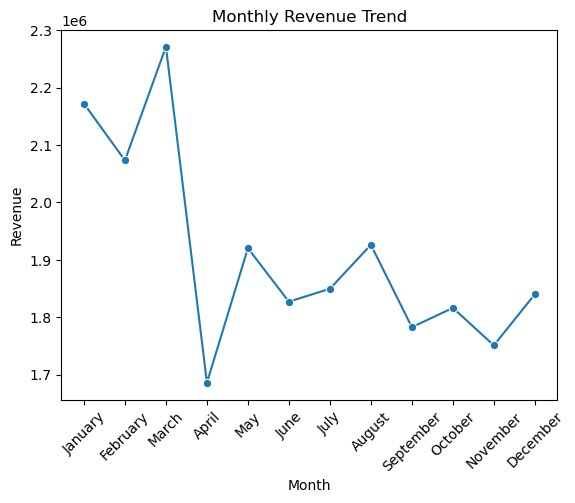

In [144]:
sns.lineplot(data=monthly_revenue, x='Month', y='Revenue', marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

### Insights
- Revenue shows variation across different months.
- Certain months generate higher sales, indicating possible seasonal trends.


In [145]:
df['Profit'] = df['Revenue'] - df['Price']

In [146]:
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,Return Rate,Month,Profit
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart,0.013986,January,4541.16
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon,0.000000,January,5866.38
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon,0.000000,January,2065.60
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart,0.000000,January,2233.73
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb,0.019108,January,5533.32


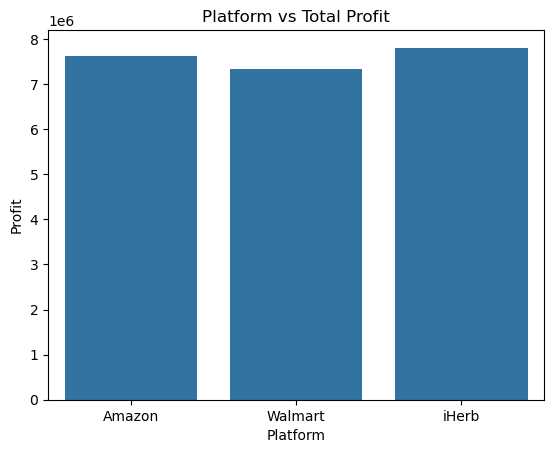

In [147]:
platform_profit = df.groupby('Platform')['Profit'].sum().reset_index()

sns.barplot(x='Platform', y='Profit', data=platform_profit)
plt.title('Platform vs Total Profit')
plt.show()

### Insights
- Total profit varies across different sales platforms.
- iHerb contributes significantly more to the overall profitability as compared to Amazon and Walmart.

## Business Recommendations

- The company should focus more on products that generate high revenue.
- Categories with higher return rates should be checked to understand the reason for returns.
- Sales strategies can be improved in locations and platforms that perform well.
- Monthly revenue trends can be used to plan promotions and marketing activities.

## Conclusion

In this project, I analyzed supplement sales data to understand revenue trends, product performance, and return patterns. Different visualizations helped identify which products, locations, and platforms generate more revenue. The analysis also showed how revenue changes over time and across categories. These insights can help businesses make better decisions about sales strategies and product management.